# Planning course graded exercice #1

In this notebook we will consider a probabilistic maze problem defined as a Markov Decision Process [scikit-decide](https://github.com/airbus/scikit-decide) domain, where the controlled agent moving in the maze can magically teleport itself upon some events.
You will then solve the problem by using one of the probabilistic algorithms provided by `scikit-decide`.

First we need to select the right planning class in `scikit-decide`'s [domain class generator](https://airbus.github.io/scikit-decide/codegen/), i.e. `MDPDomain` which is additionnally `renderable` and have `goals`.
It will generate the following domain class template:

In [49]:
from enum import Enum
from typing import *

from skdecide import *
from skdecide.builders.domain import *


# Example of State type (adapt to your needs)
class State(NamedTuple):
    x: int
    y: int


# Example of Action type (adapt to your needs)
class Action(Enum):
    up = 0
    down = 1
    left = 2
    right = 3


class D(MDPDomain, Renderable):
    T_state = State  # Type of states
    T_observation = T_state  # Type of observations
    T_event = Action  # Type of events
    T_value = float  # Type of transition values (rewards or costs)
    T_info = None  # Type of additional information in environment outcome


class MyDomain(D):
    
    def _is_terminal(self, state: D.T_state) -> D.T_predicate:
        pass
    
    def _get_transition_value(self, memory: D.T_state, action: D.T_event, next_state: Optional[D.T_state] = None) -> Value[D.T_value]:
        pass
    
    def _get_next_state_distribution(self, memory: D.T_state, action: D.T_event) -> SingleValueDistribution[D.T_state]:
        pass
    
    def _get_action_space_(self) -> Space[D.T_event]:
        pass
    
    def _get_applicable_actions_from(self, memory: D.T_state) -> Space[D.T_event]:
        pass
    
    def _get_goals_(self) -> Space[D.T_observation]:
        pass
    
    def _get_initial_state_(self) -> D.T_state:
        pass
    
    def _get_observation_space_(self) -> Space[D.T_observation]:
        pass
    
    def _render_from(self, memory: D.T_state, **kwargs: Any) -> Any:
        pass

Now, we implement a `TeleportationMazeDomain` class from this template.
We assume that whenever the agent attempts to go up, it will go back to its initial state with probability 0.9.
Every move costs 10 but 20 when we hit a wall or 1 when the agent goes through a "dollar" light green cell.
Therefore, the agent must find a compromise between going up in the middle of the maze to gather the dollars and not being teleported to the initial state.

---

## The 5 ingredients of our MDP

1. **States** — every cell `(x, y)` in the maze where the agent can be
2. **Actions** — the 4 possible directions: `up`, `down`, `left`, `right`
3. **Transitions** — when the agent picks a direction, where does it **actually** end up?
   - For `left`, `right`, `down`: it always goes where it wants (**deterministic**)
   - For `up`: it has a probability `dollar_probability` of being **teleported to the start** (**stochastic**)
4. **Costs** — every move has a price: normal cell = **10**, wall = **20**, dollar cell = **`dollar_cost`**
5. **Goal** — reach the exit cell `x` at the bottom of the maze

> **Why not just a shortest-path algorithm?** Classical algorithms like Dijkstra or A\* assume each action always gives the same result. Here, the action "up" is **random**: sometimes the agent moves up, sometimes it gets teleported back. We need an algorithm that handles this **uncertainty** — that's what an MDP solver does.

## Implementation summary

| Situation | What happens | Cost |
|---|---|---|
| Agent moves to a free cell | Normal move | **10** |
| Agent walks into a wall or out of bounds | Stays in place (wasted move) | **20** |
| Agent lands on a dollar cell ($) | Moves and gets the bonus | **`dollar_cost`** (default: 1) |
| Agent tries to go up | With probability `dollar_probability` → **teleported to start** | Depends on destination |

### Key functions implemented

- **`_get_next_state_distribution`**: defines transition probabilities. For `up`, it's a mixture between "move up normally" and "back to start".
- **`_get_transition_value`**: computes the cost of an action. When `next_state` is not provided (internal solver call), we compute the **expected cost** weighted by probabilities.
- **`_get_observation_space_`**: lists all reachable cells in the maze.

### Maze encoding

The maze is defined as ASCII text: `+`, `-`, `|` = walls, ` ` = free cell, `o` = start, `x` = goal, `$` = dollar cells.

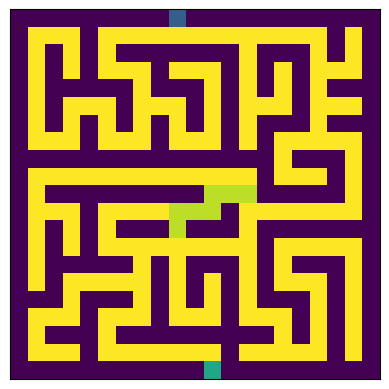

In [50]:
from enum import Enum
from typing import *
from copy import deepcopy

from skdecide import *
from skdecide.builders.domain import *
from skdecide.hub.space.gym import EnumSpace, ListSpace

# %matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


DEFAULT_MAZE = """
+-+-+-+-+o+-+-+-+-+-+
|   |             | |
+ + + +-+-+-+ +-+ + +
| | |   |   | | |   |
+ +-+-+ +-+ + + + +-+
| |   |   | |   |   |
+ + + + + + + +-+ +-+
|   |   |   | |     |
+-+-+-+-+-+-+-+ +-+ +
|             |   | |
+ +-+-+-+-+$$$+-+-+ +
|   |    $$$|       |
+ + + +-+$+-+ +-+-+-+
| | |         |     |
+ +-+-+ + +-+ + +-+ +
| |     | | | |   | |
+-+ +-+ + + + +-+ + +
|   |   |   |   | | |
+ +-+ +-+-+-+-+ + + +
|   |       |     | |
+-+-+-+-+-+x+-+-+-+-+
"""


# Example of State type (adapt to your needs)
class State(NamedTuple):
    x: int
    y: int


# Example of Action type (adapt to your needs)
class Action(Enum):
    up = 0
    down = 1
    left = 2
    right = 3


class D(MDPDomain, Goals, Renderable):
    T_state = State  # Type of states
    T_observation = T_state  # Type of observations
    T_event = Action  # Type of events
    T_value = float  # Type of transition values (rewards or costs)
    T_info = None  # Type of additional information in environment outcome


class TeleportationMazeDomain(D):

    def __init__(self, maze_str: str = DEFAULT_MAZE, dollar_cost=1.0, dollar_probability=0.9):
        maze = []
        self._dollars = []
        for y, line in enumerate(maze_str.strip().split("\n")):
            line = line.rstrip()
            row = []
            for x, c in enumerate(line):
                if c in {" ", "o", "x", "$"}:
                    row.append(1)  # spaces are 1s
                    if c == "o":
                        self._start = State(x, y)
                    if c == "x":
                        self._goal = State(x, y)
                    if c == "$":
                        self._dollars.append(State(x, y))
                else:
                    row.append(0)  # walls are 0s
            maze.append(row)
        self._maze = maze
        self._num_cols = len(maze[0])
        self._num_rows = len(maze)
        self._dollar_cost = dollar_cost
        self._dollar_probability = dollar_probability
        self._ax = None
        self._fig = None
        self._image = None

    def _is_terminal(self, state: D.T_state) -> D.T_predicate:
        return state == self._goal

    def _get_transition_value(self, memory: D.T_state, action: D.T_event, next_state: Optional[D.T_state] = None) -> Value[D.T_value]:
        if action == Action.left:
            candidate = State(memory.x - 1, memory.y)
        elif action == Action.right:
            candidate = State(memory.x + 1, memory.y)
        elif action == Action.up:
            candidate = State(memory.x, memory.y - 1)
        elif action == Action.down:
            candidate = State(memory.x, memory.y + 1)
        else:
            return Value(cost=20.0)

        valid_move = (
            0 <= candidate.x < self._num_cols
            and 0 <= candidate.y < self._num_rows
            and self._maze[candidate.y][candidate.x] == 1
        )

        if not valid_move:
            return Value(cost=20.0)

        def state_cost(s: State) -> float:
            return self._dollar_cost if s in self._dollars else 10.0

        if next_state is not None:
            return Value(cost=state_cost(next_state))

        if action == Action.up:
            teleport_prob = min(1.0, max(0.0, float(self._dollar_probability)))
            return Value(
                cost=teleport_prob * state_cost(self._start)
                + (1.0 - teleport_prob) * state_cost(candidate)
            )

        return Value(cost=state_cost(candidate))

    def _get_next_state_distribution(self, memory: D.T_state, action: D.T_event) -> DiscreteDistribution[D.T_state]:
        if action == Action.left:
            candidate = State(memory.x - 1, memory.y)
        elif action == Action.right:
            candidate = State(memory.x + 1, memory.y)
        elif action == Action.up:
            candidate = State(memory.x, memory.y - 1)
        elif action == Action.down:
            candidate = State(memory.x, memory.y + 1)
        else:
            return DiscreteDistribution([(memory, 1.0)])

        valid_move = (
            0 <= candidate.x < self._num_cols
            and 0 <= candidate.y < self._num_rows
            and self._maze[candidate.y][candidate.x] == 1
        )

        if not valid_move:
            return DiscreteDistribution([(memory, 1.0)])

        if action == Action.up:
            teleport_prob = min(1.0, max(0.0, float(self._dollar_probability)))
            if candidate == self._start:
                return DiscreteDistribution([(self._start, 1.0)])
            return DiscreteDistribution([
                (self._start, teleport_prob),
                (candidate, 1.0 - teleport_prob),
            ])

        return DiscreteDistribution([(candidate, 1.0)])

    def _get_action_space_(self) -> Space[D.T_event]:
        return EnumSpace(Action)

    def _get_applicable_actions_from(self, memory: D.T_state) -> Space[D.T_event]:
        if memory == self._goal:
            return ListSpace([Action.down])
        transitions = [
            (Action.left, State(memory.x - 1, memory.y)),
            (Action.right, State(memory.x + 1, memory.y)),
            (Action.up, State(memory.x, memory.y - 1)),
            (Action.down, State(memory.x, memory.y + 1))
        ]
        applicable_actions = []
        for tr in transitions:
            if (
                0 <= tr[1].x < self._num_cols
                and 0 <= tr[1].y < self._num_rows
                and self._maze[tr[1].y][tr[1].x] == 1
            ):
                applicable_actions.append(tr[0])
        assert len(applicable_actions) > 0
        return ListSpace(applicable_actions)

    def _get_goals_(self) -> Space[D.T_observation]:
        return ListSpace([self._goal])

    def _get_initial_state_(self) -> D.T_state:
        return self._start

    def _get_observation_space_(self) -> Space[D.T_observation]:
        reachable_states = [
            State(x, y)
            for y in range(self._num_rows)
            for x in range(self._num_cols)
            if self._maze[y][x] == 1
        ]
        return ListSpace(reachable_states)

    def _render_from(self, memory: D.T_state, **kwargs: Any) -> Any:
        if self._ax is None:
            fig, ax = plt.subplots(1)
            #fig.canvas.set_window_title("Maze")
            ax.set_aspect("equal")  # set the x and y axes to the same scale
            plt.xticks([])  # remove the tick marks by setting to an empty list
            plt.yticks([])  # remove the tick marks by setting to an empty list
            ax.invert_yaxis()  # invert the y-axis so the first row of data is at the top
            self._ax = ax
            self._fig = fig
            plt.ion()
        maze = deepcopy(self._maze)
        for d in self._dollars:
            maze[d.y][d.x] = 0.9
        maze[self._goal.y][self._goal.x] = 0.6
        maze[memory.y][memory.x] = 0.3
        if 'path' in kwargs:
            for s in kwargs.get('path'):
                maze[s.y][s.x] = 0.5
        if self._image is None:
            self._image = self._ax.imshow(maze)
        else:
            self._image.set_data(maze)
        display(self._fig)
        clear_output(wait = True)
        plt.pause(0.001)

maze = TeleportationMazeDomain()
maze.render(maze._get_initial_state_())

Now, we solve the domain with the LRTDP solver, which is a famous extension of the LRTA* solver to solve Stochastic Shortest Path problems.

---

### How LRTDP works (in simple terms)

1. **Explore**: the agent simulates trips through the maze from the start
2. **Evaluate**: at each visited cell, it updates its estimate of the remaining cost to reach the exit
3. **Converge**: after enough simulations, the estimates stabilize → we have found the **optimal policy**

### Parameters used

| Parameter | Value | Role |
|---|---|---|
| `heuristic` | Euclidean distance to goal | Guides exploration toward the exit (like a "sense of direction") |
| `discount` | 1.0 | No future discounting (every cost matters equally) |
| `epsilon` | 0.001 | Convergence precision (stop when estimates change by less than 0.1%) |

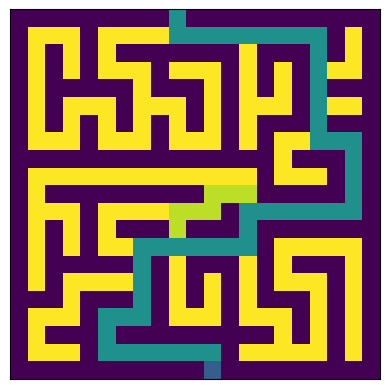

In [51]:
from skdecide.hub.solver.lrtdp import LRTDP
from skdecide.utils import rollout

from math import sqrt

domain_factory = lambda: TeleportationMazeDomain(maze_str=DEFAULT_MAZE, dollar_cost=1.0, dollar_probability=0.9)

solver_factory = lambda: LRTDP(
    domain_factory=domain_factory,
    heuristic=lambda d, s: Value(cost=sqrt((d._goal.x - s.x)**2 + (d._goal.y - s.y)**2)),
    discount=1.0,
    epsilon=0.001,
    parallel=False,
    verbose=False,
)

with solver_factory() as solver:
    solver.solve()

    plan = []
    cost = 0
    evaluation_domain = domain_factory()
    observation = evaluation_domain.reset()
    path = [observation]
    nb_steps = 0
    while (not evaluation_domain.is_goal(observation)) and nb_steps < 1000:
        plan.append(solver.sample_action(observation))
        outcome = evaluation_domain.step(plan[-1])
        cost += outcome.value.cost
        observation = outcome.observation
        path.append(observation)
        nb_steps += 1

    # --- Summary ---
    used_dollars = any(s in evaluation_domain._dollars for s in path)
    reached_goal = evaluation_domain.is_goal(observation)

    print("=" * 50)
    print("  RESULT - Default configuration")
    print("  dollar_cost=1.0, dollar_probability=0.9")
    print("=" * 50)
    print(f"  Goal reached   : {'Yes' if reached_goal else 'No'}")
    print(f"  Steps          : {nb_steps}")
    print(f"  Total cost     : {cost:.1f}")
    print(f"  Used dollars   : {'Yes' if used_dollars else 'No'}")
    print("=" * 50)
    if not used_dollars:
        print("  -> The robot avoids dollars because the")
        print("     teleportation risk (90%) is too high!")
    print()

    for i, s in enumerate(path):
        evaluation_domain.render(s, path=path[:i])

Now play with different `dollar_cost` and `dollar_probability` until finding a path that goes through the dollars in the maze.
Please comment your findings.

---

### Intuition behind the two parameters

| Parameter | Effect when it **decreases** |
|---|---|
| `dollar_cost` | Dollar cells become more attractive (bigger bonus) |
| `dollar_probability` | Going up becomes less risky (fewer teleportations) |

For the agent to go through dollars, **both conditions** must be met: bonus worth the detour + acceptable teleportation risk.

### Experiment design

To properly isolate each parameter's effect, we explore **three axes**:

1. **Axis 1 — Vary `dollar_cost` only** (with `dollar_probability` fixed low at 0.1)
2. **Axis 2 — Vary `dollar_probability` only** (with `dollar_cost` fixed low at 0.5)
3. **Axis 3 — Full grid**: sweep all combinations to find the best trade-off

Each configuration is tested over **20 rollouts** because the environment is stochastic — a single trial is not reliable.

| Metric | What it measures |
|---|---|
| **Success rate** | Does the agent reach the exit (within 400 steps)? |
| **Dollar path rate** | Does the agent pass through at least one $ cell? |
| **Average cost** | How expensive is the trip on average? |

AXIS 1: Varying dollar_cost (dollar_probability = 0.1)
  dollar_cost= 10.0  |  success=100%  |  dollar_path=  0%  |  avg_cost= 500.0
  dollar_cost=  5.0  |  success=100%  |  dollar_path=  0%  |  avg_cost= 500.0
  dollar_cost=  2.0  |  success=100%  |  dollar_path=100%  |  avg_cost= 464.0 <-- dollars!
  dollar_cost=  1.0  |  success=100%  |  dollar_path=100%  |  avg_cost= 513.0 <-- dollars!
  dollar_cost=  0.5  |  success=100%  |  dollar_path=100%  |  avg_cost= 467.5 <-- dollars!
  dollar_cost=  0.1  |  success=100%  |  dollar_path=100%  |  avg_cost= 520.7 <-- dollars!

AXIS 2: Varying dollar_probability (dollar_cost = 0.5)
  dollar_prob=0.00  |  success=100%  |  dollar_path=100%  |  avg_cost= 453.5 <-- dollars!
  dollar_prob=0.05  |  success=100%  |  dollar_path=100%  |  avg_cost= 495.5 <-- dollars!
  dollar_prob=0.10  |  success=100%  |  dollar_path=100%  |  avg_cost= 509.5 <-- dollars!
  dollar_prob=0.20  |  success=100%  |  dollar_path=  0%  |  avg_cost= 500.0
  dollar_prob=0.40  | 

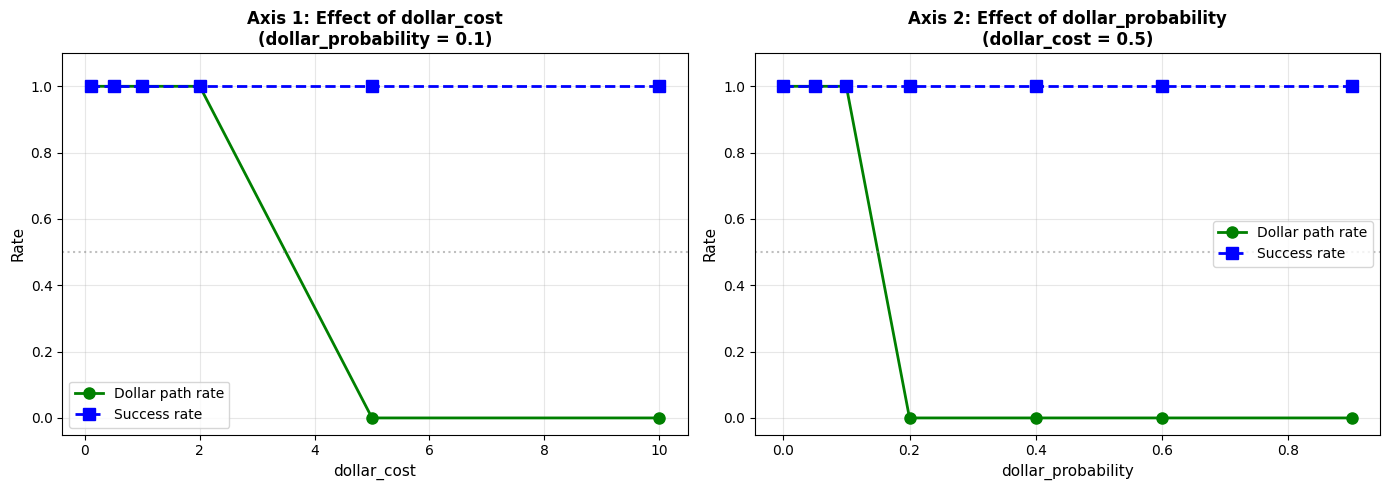

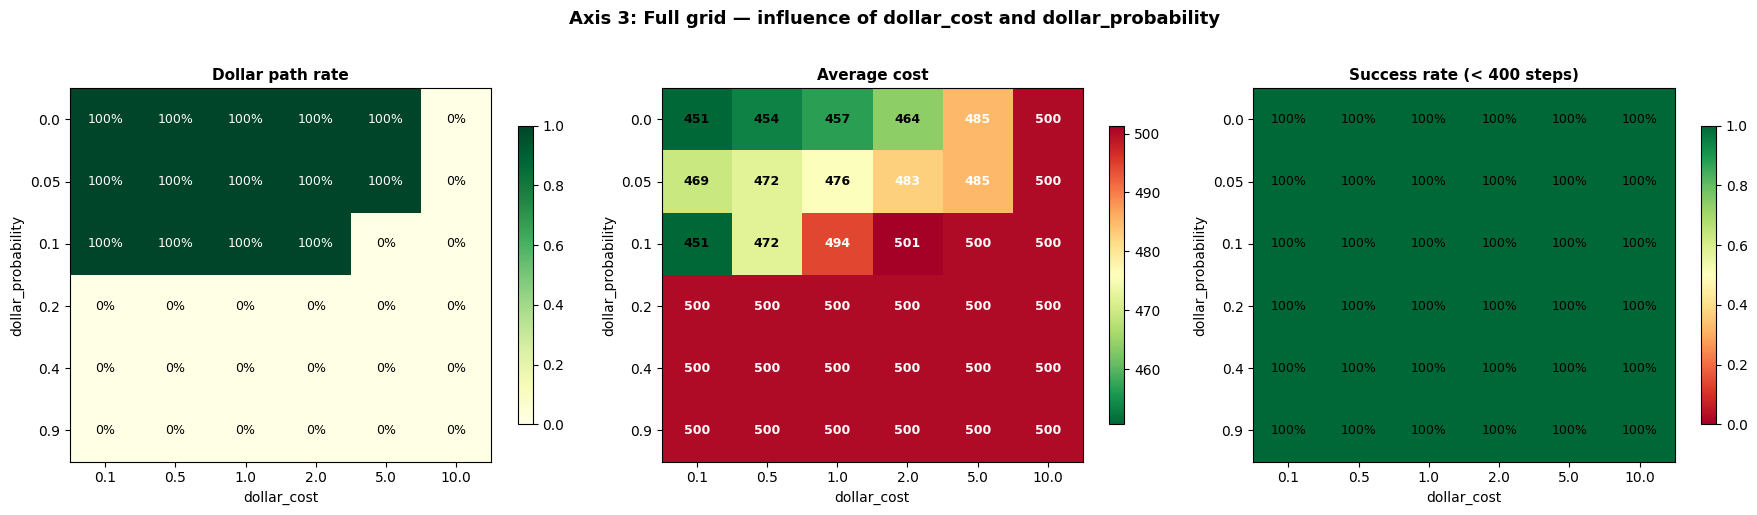

In [52]:
from math import sqrt
import matplotlib.pyplot as plt
import numpy as np

# ===============================================================
# Evaluation function: solve the MDP then simulate N rollouts
# ===============================================================

def evaluate_setting(dollar_cost: float, dollar_probability: float,
                     n_rollouts: int = 20, max_steps: int = 400):
    """Solve the maze and measure performance over multiple simulations."""
    domain_factory = lambda: TeleportationMazeDomain(
        maze_str=DEFAULT_MAZE,
        dollar_cost=dollar_cost,
        dollar_probability=dollar_probability,
    )
    solver_factory = lambda: LRTDP(
        domain_factory=domain_factory,
        heuristic=lambda d, s: Value(cost=sqrt((d._goal.x - s.x)**2 + (d._goal.y - s.y)**2)),
        discount=1.0, epsilon=0.001, parallel=False, verbose=False,
    )

    with solver_factory() as solver:
        solver.solve()
        total_costs, successes, dollar_uses = [], 0, 0

        for _ in range(n_rollouts):
            env = domain_factory()
            obs = env.reset()
            path, cost, steps = [obs], 0.0, 0

            while not env.is_goal(obs) and steps < max_steps:
                action = solver.sample_action(obs)
                outcome = env.step(action)
                cost += outcome.value.cost
                obs = outcome.observation
                path.append(obs)
                steps += 1

            successes += int(env.is_goal(obs))
            dollar_uses += int(any(s in env._dollars for s in path))
            total_costs.append(cost)

    return {
        "dc": dollar_cost, "dp": dollar_probability,
        "success": successes / n_rollouts,
        "dollars": dollar_uses / n_rollouts,
        "avg_cost": np.mean(total_costs),
    }


# ===============================================================
# AXIS 1: Effect of dollar_cost (dollar_probability fixed at 0.1)
# ===============================================================
print("=" * 65)
print("AXIS 1: Varying dollar_cost (dollar_probability = 0.1)")
print("=" * 65)

dc_values = [10.0, 5.0, 2.0, 1.0, 0.5, 0.1]
axis1 = [evaluate_setting(dc, 0.1) for dc in dc_values]

for r in axis1:
    tag = " <-- dollars!" if r["dollars"] > 0.5 else ""
    print(f"  dollar_cost={r['dc']:5.1f}  |  success={r['success']:4.0%}  |  "
          f"dollar_path={r['dollars']:4.0%}  |  avg_cost={r['avg_cost']:6.1f}{tag}")


# ===============================================================
# AXIS 2: Effect of dollar_probability (dollar_cost fixed at 0.5)
# ===============================================================
print("\n" + "=" * 65)
print("AXIS 2: Varying dollar_probability (dollar_cost = 0.5)")
print("=" * 65)

dp_values = [0.0, 0.05, 0.1, 0.2, 0.4, 0.6, 0.9]
axis2 = [evaluate_setting(0.5, dp) for dp in dp_values]

for r in axis2:
    tag = " <-- dollars!" if r["dollars"] > 0.5 else ""
    print(f"  dollar_prob={r['dp']:4.2f}  |  success={r['success']:4.0%}  |  "
          f"dollar_path={r['dollars']:4.0%}  |  avg_cost={r['avg_cost']:6.1f}{tag}")


# ===============================================================
# AXIS 3: Full grid (heatmap)
# ===============================================================
print("\n" + "=" * 65)
print("AXIS 3: Full grid - exploring all combinations")
print("=" * 65)

dc_grid = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
dp_grid = [0.0, 0.05, 0.1, 0.2, 0.4, 0.9]

grid_results = []
for dp in dp_grid:
    row = []
    for dc in dc_grid:
        r = evaluate_setting(dc, dp, n_rollouts=15)
        row.append(r)
        print(f"  dc={dc:5.1f}, dp={dp:.2f} -> dollars={r['dollars']:.0%}, success={r['success']:.0%}, cost={r['avg_cost']:.0f}")
    grid_results.append(row)

# ===============================================================
# LINE CHARTS PER AXIS
# ===============================================================
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Axis 1: dollar_cost
ax1.plot([r["dc"] for r in axis1], [r["dollars"] for r in axis1],
         "go-", linewidth=2, markersize=8, label="Dollar path rate")
ax1.plot([r["dc"] for r in axis1], [r["success"] for r in axis1],
         "bs--", linewidth=2, markersize=8, label="Success rate")
ax1.set_xlabel("dollar_cost", fontsize=11)
ax1.set_ylabel("Rate", fontsize=11)
ax1.set_title("Axis 1: Effect of dollar_cost\n(dollar_probability = 0.1)",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.set_ylim(-0.05, 1.1)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)

# Axis 2: dollar_probability
ax2.plot([r["dp"] for r in axis2], [r["dollars"] for r in axis2],
         "go-", linewidth=2, markersize=8, label="Dollar path rate")
ax2.plot([r["dp"] for r in axis2], [r["success"] for r in axis2],
         "bs--", linewidth=2, markersize=8, label="Success rate")
ax2.set_xlabel("dollar_probability", fontsize=11)
ax2.set_ylabel("Rate", fontsize=11)
ax2.set_title("Axis 2: Effect of dollar_probability\n(dollar_cost = 0.5)",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.set_ylim(-0.05, 1.1)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()



# --- Heatmaps ---
dollar_matrix = np.array([[r["dollars"] for r in row] for row in grid_results])
cost_matrix = np.array([[r["avg_cost"] for r in row] for row in grid_results])
success_matrix = np.array([[r["success"] for r in row] for row in grid_results])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap 1: dollar path rate
im1 = axes[0].imshow(dollar_matrix, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
axes[0].set_title("Dollar path rate", fontsize=11, fontweight="bold")
axes[0].set_xlabel("dollar_cost")
axes[0].set_ylabel("dollar_probability")
axes[0].set_xticks(range(len(dc_grid)))
axes[0].set_xticklabels([str(v) for v in dc_grid])
axes[0].set_yticks(range(len(dp_grid)))
axes[0].set_yticklabels([str(v) for v in dp_grid])
for i in range(len(dp_grid)):
    for j in range(len(dc_grid)):
        axes[0].text(j, i, f"{dollar_matrix[i, j]:.0%}", ha="center", va="center",
                     color="black" if dollar_matrix[i, j] < 0.7 else "white", fontsize=9)
fig.colorbar(im1, ax=axes[0], shrink=0.8)

# Heatmap 2: average cost
im2 = axes[1].imshow(cost_matrix, cmap="RdYlGn_r", aspect="auto")
axes[1].set_title("Average cost", fontsize=11, fontweight="bold")
axes[1].set_xlabel("dollar_cost")
axes[1].set_ylabel("dollar_probability")
axes[1].set_xticks(range(len(dc_grid)))
axes[1].set_xticklabels([str(v) for v in dc_grid])
axes[1].set_yticks(range(len(dp_grid)))
axes[1].set_yticklabels([str(v) for v in dp_grid])
for i in range(len(dp_grid)):
    for j in range(len(dc_grid)):
        mid = (cost_matrix.min() + cost_matrix.max()) / 2
        axes[1].text(j, i, f"{cost_matrix[i, j]:.0f}", ha="center", va="center",
                     color="white" if cost_matrix[i, j] > mid else "black", fontsize=9, fontweight="bold")
fig.colorbar(im2, ax=axes[1], shrink=0.8)

# Heatmap 3: success rate
im3 = axes[2].imshow(success_matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[2].set_title("Success rate (< 400 steps)", fontsize=11, fontweight="bold")
axes[2].set_xlabel("dollar_cost")
axes[2].set_ylabel("dollar_probability")
axes[2].set_xticks(range(len(dc_grid)))
axes[2].set_xticklabels([str(v) for v in dc_grid])
axes[2].set_yticks(range(len(dp_grid)))
axes[2].set_yticklabels([str(v) for v in dp_grid])
for i in range(len(dp_grid)):
    for j in range(len(dc_grid)):
        axes[2].text(j, i, f"{success_matrix[i, j]:.0%}", ha="center", va="center",
                     color="black" if success_matrix[i, j] > 0.5 else "white", fontsize=9)
fig.colorbar(im3, ax=axes[2], shrink=0.8)

plt.suptitle("Axis 3: Full grid — influence of dollar_cost and dollar_probability",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()